In [3]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\08-Linear-Regression-Models\Advertising.csv")

In [41]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [42]:
X = df.drop('sales', axis=1)
y = df['sales']

In [43]:
from sklearn.preprocessing import PolynomialFeatures

In [44]:
polynomial_convertor = PolynomialFeatures(degree=2, include_bias=False)

In [45]:
#только анализирует данные: max/min, ... . Новую модель не создает! 
# признаки полиномиальные тоже не создает! просто готовим признаки для модели
polynomial_convertor.fit(X)

PolynomialFeatures(include_bias=False)

In [46]:
poly_features = polynomial_convertor.transform(X)


In [47]:
poly_features.shape

(200, 9)

In [48]:
pd.DataFrame(poly_features, columns=polynomial_convertor.get_feature_names_out(X.columns))

,TV,radio,newspaper,TV^2,TV radio,TV newspaper,radio^2,radio newspaper,newspaper^2
0,230.1,37.8,69.2,52946.01,8697.78,15922.92,1428.84,2615.76,4788.64
1,44.5,39.3,45.1,1980.25,1748.85,2006.95,1544.49,1772.43,2034.01
2,17.2,45.9,69.3,295.84,789.48,1191.96,2106.81,3180.87,4802.49
3,151.5,41.3,58.5,22952.25,6256.95,8862.75,1705.69,2416.05,3422.25
4,180.8,10.8,58.4,32688.64,1952.64,10558.72,116.64,630.72,3410.56
...,...,...,...,...,...,...,...,...,...
195,38.2,3.7,13.8,1459.24,141.34,527.16,13.69,51.06,190.44
196,94.2,4.9,8.1,8873.64,461.58,763.02,24.01,39.69,65.61
197,177.0,9.3,6.4,31329.00,1646.10,1132.80,86.49,59.52,40.96
198,283.6,42.0,66.2,80428.96,11911.20,18774.32,1764.00,2780.40,4382.44


In [49]:
X.shape

(200, 3)

3 признака превратились в 9. 

In [50]:
X.iloc[0]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

In [51]:
poly_features.shape

(200, 9)

In [52]:
poly_features[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

Первые 3 числа - исходные признаки. Далее - interactions - перемножения друг на друга. 

230,1 * 37,8=8697,78 - это число ЕСТЬ в новых признаках. TV * radio, TV * newspaper, newspaper * radio. В датафрейме они могут располагаться не по порядку.

Еще 3 признака - квадраты исходных признаков.

In [53]:
poly_features[0][:3]

array([230.1,  37.8,  69.2])

In [17]:
#polynomial_convertor.fit_transform(X)

In [18]:
from sklearn.model_selection import train_test_split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

In [7]:
from sklearn.linear_model import LinearRegression

In [56]:
model = LinearRegression(fit_intercept=True)

In [57]:
model.fit(X_train, y_train)

LinearRegression()

In [58]:
test_predictions = model.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [59]:
MAE = mean_absolute_error(y_test, test_predictions)
MSE = mean_squared_error(y_test, test_predictions)
RMSE = np.sqrt(MSE)

In [60]:
MAE

0.48967980448035886

In [61]:
RMSE

np.float64(0.6646431757269)

In [62]:
df['sales'].mean()

np.float64(14.0225)

Теперь сравним метрики с работой прошлой модели!

MAE = 1,213

RMSE = 1,516

Благодаря параметрам **(test_size=0.3, random_state=101)** мы можем быть уверены, что в обучающий и тестовый наборы данных \
попали одни и те же данные

Полиномиальная регрессия работает лучше обычной линейной

In [28]:
model.coef_

array([ 5.17095811e-02,  1.30848864e-02,  1.20000085e-02, -1.10892474e-04,
        1.14212673e-03, -5.24100082e-05,  3.34919737e-05,  1.46380310e-04,
       -3.04715806e-05])

In [29]:
pd.DataFrame([model.coef_], columns=polynomial_convertor.get_feature_names_out(X.columns))

,TV,radio,newspaper,TV^2,TV radio,TV newspaper,radio^2,radio newspaper,newspaper^2
0,0.05171,0.013085,0.012,-0.000111,0.001142,-0.000052,0.000033,0.000146,-0.00003


## **Дилемма смещения-дисперсии (Bias-Variance Trade-Off)**

*Недообучение и переобучение*

***Недообучение*** - модель плохо уловила основной тренд на обучающих данных, => делает плохие предсказания.

Будет высокий **bias (смещение)** - насколько сильно среднее предсказанное значение отличается от среднего истинного значения

***Переобучение*** - модель слишком сильно запомнила шумы данных, очень чувствительна к данным. Будет идеально работать на обучающих данных, но предсказания будут сильно скакать.

Будет высокий **variance (дисперсия)** - насколько сильно отличаются предсказания в зависимости от выборки.

Пример (натянутый): есть данные из 20 точек.

Недообученная модель проходит только через 2 точки.

Обученная модель проходит через все 20 точек.

И тот, и другой случай - *плохо*!

Задача состоит в том, чтобы найти идеальный баланс между сложностью модели и ошибкой.

#### Настройка сложности модели
Для полиномиальной регрессии сложность - степень полинома.

Нужно обращать внимание на ошибки и на тестовом, и на обучающем наборах данных, и искать нужную зависимость ошибки от степени полинома

**Задача**: создать цикл, внутри которого мы будем разбивать данные на тестовый и обучающий наборы, создавать модели для разных степеней полинома, вычислять метрики, и найти идеальную степень, когда ошибки не поползут вверх, т.е. не наступит переобученность. Потом мы нарисуем график зависимости

In [63]:
# Ошибка на обучающем наборе для той или иной степени полинома
train_rmse_errors = []
# Ошибка на тестовом наборе для той или иной степени полинома
test_rmse_errors = []

for d in range(1,10):
    
    # Создаём полиномиальные данные для степени "d"
    polynomial_converter = PolynomialFeatures(degree=d,include_bias=False)
    poly_features = polynomial_converter.fit_transform(X)
    
    # Разбиваем эти новые полиномиальные данные на обучающий и тестовый наборы данных
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
    
    # Обучаем модель на этом новом наборе полиномиальных данных
    model = LinearRegression(fit_intercept=True)
    model.fit(X_train,y_train)
    
    # Выполняем предсказание и на обучающем, и на тестовом наборе данных
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Вычисляем ошибки
    
    # Ошибки на обучающем наборе данных
    train_RMSE = np.sqrt(mean_squared_error(y_train,train_pred))
    
    # Ошибки на тестовом наборе данных
    test_RMSE = np.sqrt(mean_squared_error(y_test,test_pred))

    # Добавляем ошибки в список для последующего нанесения на график
       
    train_rmse_errors.append(train_RMSE)
    test_rmse_errors.append(test_RMSE)

In [64]:
train_rmse_errors

[np.float64(1.734594124329376),
 np.float64(0.5879574085292234),
 np.float64(0.43393443569020657),
 np.float64(0.35170836883993556),
 np.float64(0.2509342923789987),
 np.float64(0.20953728390810636),
 np.float64(0.220468592026013),
 np.float64(0.27150074924450723),
 np.float64(0.5132041534764078)]

In [65]:
test_rmse_errors

[np.float64(1.5161519375993877),
 np.float64(0.6646431757269),
 np.float64(0.5803286825219469),
 np.float64(0.5077742640851456),
 np.float64(2.575819388953378),
 np.float64(9.87141360632477),
 np.float64(41.33052004954889),
 np.float64(3108.5907535489564),
 np.float64(12767.649350485362)]

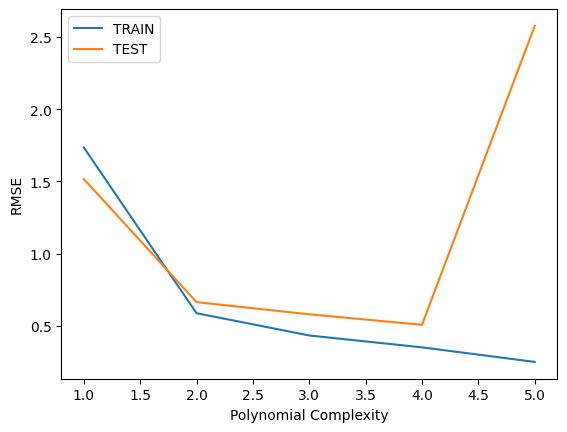

In [68]:
plt.plot(range(1,6),train_rmse_errors[:5],label='TRAIN')
plt.plot(range(1,6),test_rmse_errors[:5],label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

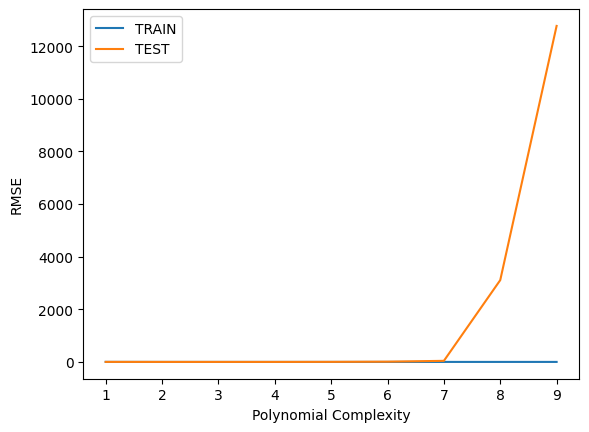

In [70]:
plt.plot(range(1,10), train_rmse_errors, label='TRAIN')
plt.plot(range(1,10),test_rmse_errors,label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

### Внедрение модели

Учитывая предметную область, мы выбрали не 4ую степень полинома, а 3. Еще 4 степень - граница того, когда ошибка на тестовых данных начинает взрывной рост

In [71]:
final_poly_convertor = PolynomialFeatures(degree=3, include_bias=False)

In [72]:
full_converted_X = final_poly_convertor.fit_transform(X)

In [73]:
final_model = LinearRegression()

In [74]:
final_model.fit(full_converted_X,y)

LinearRegression()

In [75]:
from joblib import dump, load

In [76]:
dump(final_model, 'final_poly_model.joblib')

['final_poly_model.joblib']

In [77]:
dump(final_poly_convertor, 'final_poly_convertor.joblib')

['final_poly_convertor.joblib']

In [78]:
loaded_convertor = load('final_poly_convertor.joblib')

In [79]:
loaded_model = load('final_poly_model.joblib')

In [88]:
campaign = pd.DataFrame(np.array([[149,22,12]]),columns=['TV', 'radio', 'newspaper'])

In [89]:
loaded_convertor.transform(campaign)

array([[1.490000e+02, 2.200000e+01, 1.200000e+01, 2.220100e+04,
        3.278000e+03, 1.788000e+03, 4.840000e+02, 2.640000e+02,
        1.440000e+02, 3.307949e+06, 4.884220e+05, 2.664120e+05,
        7.211600e+04, 3.933600e+04, 2.145600e+04, 1.064800e+04,
        5.808000e+03, 3.168000e+03, 1.728000e+03]])

In [90]:
loaded_convertor.transform(campaign).shape

(1, 19)

In [91]:
transformed_data = loaded_convertor.transform(campaign)

In [92]:
loaded_model.predict(transformed_data)

array([14.64501014])

In [14]:
X = np.random.rand(50,1) * 10
y = 2.5 * X + 1.5 + np.random.randn(50, 1)

In [15]:
model = LinearRegression()

In [16]:
model.fit(X,y)

LinearRegression()

In [17]:
X_new = np.array([[0], [2]])
y_new = model.predict(X_new)

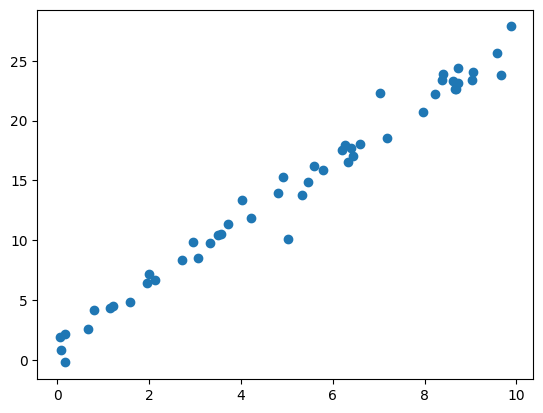

In [18]:
plt.figure()
plt.scatter(X,y)
plt.plot()